CUDA GPU found, performing calculations on GPU
Using form factor calculated from file: c:\Users\Ansh\Projects\DarkMatterRates\modulation_study\..\DMeRates\../form_factors/QCDark/Si_final.hdf5


c:\Users\Ansh\anaconda3\envs\dmerates\Lib\site-packages\torchquad\integration\simpson.py:76: UserWarning: N per dimension cannot be even due to necessary subdivisions. N per dim will now be changed to the next lower integer, i.e. 1250 -> 1249.
  warnings.warn(


CUDA GPU found, performing calculations on GPU
Using form factor calculated from file: c:\Users\Ansh\Projects\DarkMatterRates\modulation_study\..\DMeRates\../form_factors/QCDark/Si_final.hdf5
CUDA GPU found, performing calculations on GPU
Using form factor calculated from file: c:\Users\Ansh\Projects\DarkMatterRates\modulation_study\..\DMeRates\../form_factors/QCDark/Si_final.hdf5


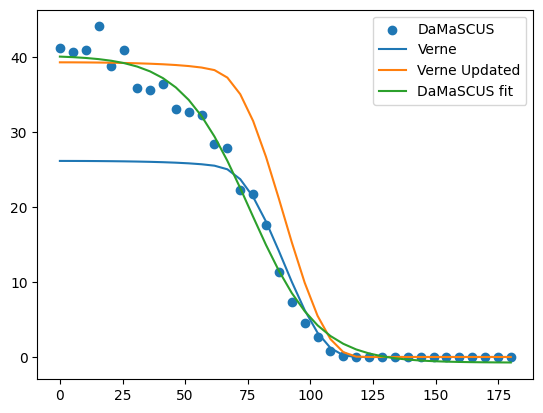

In [85]:
from Modulation import get_modulated_rates,get_angle_limits,fitted_rates
import numericalunits as nu
import matplotlib.pyplot as plt
import numpy as np

min_,max_ = get_angle_limits('SNO',date=[3,8,2024])

sigmaE = 1e-31
i,r_v = get_modulated_rates('Si',0.64,sigmaE,2,ne=1,useVerne=True,summer=False)
i,r_v_new = get_modulated_rates('Si',0.642,sigmaE,2,ne=1,useVerne=True,summer=False)
i,r_d = get_modulated_rates('Si',0.642,sigmaE,2,ne=1,useVerne=False,summer=False)
r_v = r_v.flatten().numpy()
r_v_new = r_v_new.flatten().numpy()
r_d = r_d.flatten().numpy()

r_v = r_v * nu.g* nu.day
r_v_new = r_v_new * nu.g* nu.day
r_d = r_d * nu.g* nu.day
angle_grid, fit_vector, parameters, errors = fitted_rates(i,r_d,rates_err=None,linear=False)
r_d_fit = fit_vector[0]
plt.scatter(i,r_d,label='DaMaSCUS')

plt.plot(i,r_v,label='Verne')
plt.plot(i,r_v_new,label='Verne Updated')
plt.plot(angle_grid,r_d_fit,label='DaMaSCUS fit')
# plt.xlim(min_,max_)
plt.legend()
plt.show()
plt.close()


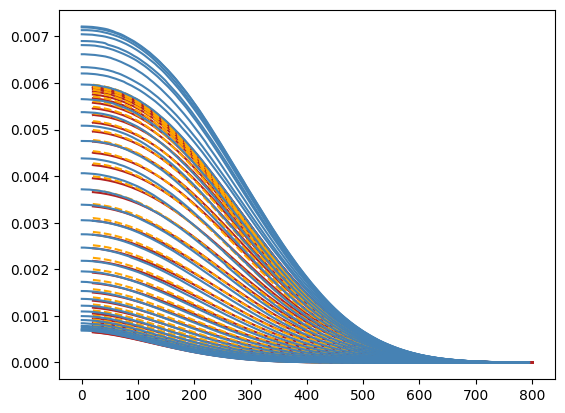

In [86]:
import os
verne_dir= '/Users/Ansh/Projects/DarkMatterRates/halo_data/modulated/FDMq2/Verne/mDM_0_642_MeV_sigmaE_1e-31_cm2/'
verne_dir_old= '/Users/Ansh/Projects/DarkMatterRates/halo_data/modulated/FDMq2/Verne/mDM_0_64_MeV_sigmaE_1e-31_cm2/'

damascus_dir= '/Users/Ansh/Projects/DarkMatterRates/halo_data/modulated/FDMq2/DaMaSCUS/mDM_0_642_MeV_sigmaE_1e-31_cm2/'

files = os.listdir(verne_dir)
for f in files:
    dam_data = np.loadtxt(verne_dir + f)
    vmin = dam_data[:,0]
    eta = dam_data[:,1]
    plt.plot(vmin,eta,color='firebrick')

files = os.listdir(verne_dir_old)
for f in files:
    dam_data = np.loadtxt(verne_dir_old + f)
    vmin = dam_data[:,0]
    eta = dam_data[:,1]
    plt.plot(vmin,eta,color='orange',ls='--')

files = os.listdir(damascus_dir)
for f in files:
    dam_data = np.loadtxt(damascus_dir + f)
    vmin = dam_data[:,0]
    eta = dam_data[:,1]
    plt.plot(vmin,eta,color='steelblue')



<>:50: SyntaxWarning: invalid escape sequence '\c'
<>:50: SyntaxWarning: invalid escape sequence '\c'
C:\Users\Ansh\AppData\Local\Temp\ipykernel_30384\1115075342.py:50: SyntaxWarning: invalid escape sequence '\c'
  plt.title(f"$m_\chi$ = 0.6 MeV, $\sigma_e$ ={sigmaE}")


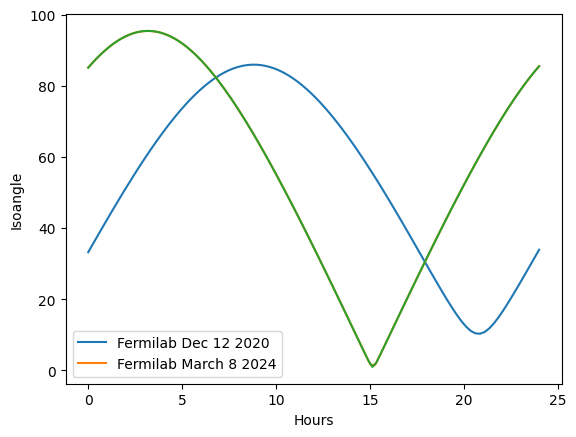

original verne:  26.147461373023194 7.851926081848483 9.147767645587356
damascus:  40.04277918887301 7.098512086885415 16.4721335509938
updated verne:  39.29923760602857 12.202574968588882 13.548331318719843


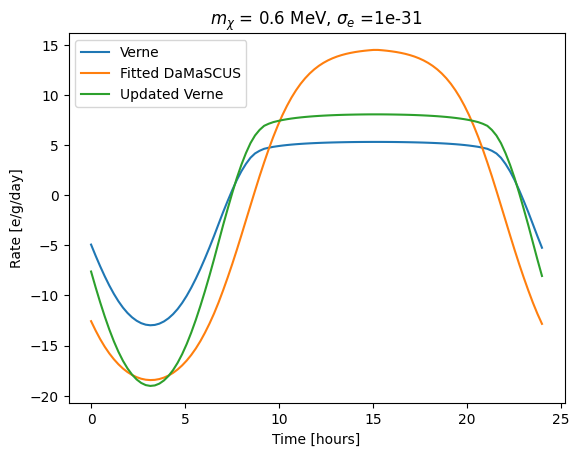

In [90]:
from scipy.interpolate import Akima1DInterpolator
from isoangle import *

numpoints = 100
hours = np.linspace(0,24,numpoints)

nlist1 = [FracDays(np.array([12,12,2020]),np.array([h,0,0])) for h in hours]


isoFNAL, = plt.plot(hours,[np.rad2deg(ThetaIso(sites['FNAL']['loc'],n)) for n in nlist1], label='Fermilab Dec 12 2020')


nlist2 = [FracDays(np.array([8,3,2024]),np.array([h,0,0])) for h in  hours]

np.array([np.rad2deg(ThetaIso(sites['FNAL']['loc'],n)) for n in nlist1])

isoFNAL, = plt.plot(hours,[np.rad2deg(ThetaIso(sites['FNAL']['loc'],n)) for n in nlist2], label='Fermilab March 8 2024')
angles_by_hour = np.array([np.rad2deg(ThetaIso(sites['FNAL']['loc'],n)) for n in nlist2])
angle_interp = Akima1DInterpolator(hours,angles_by_hour)


plt.plot(np.linspace(0,24,120),angle_interp(np.linspace(0,24,120)))
plt.xlabel("Hours")
plt.ylabel("Isoangle")

plt.legend()
plt.show()
plt.close()

# hours_by_angle = hours[np.argsort(angles_by_hour)]
# angles_by_hour = np.sort(angles_by_hour)

rate_per_angle_verne = Akima1DInterpolator(i,r_v)
rate_per_angle_verne_new = Akima1DInterpolator(i,r_v_new)
rate_per_angle_damascus = Akima1DInterpolator(angle_grid,r_d_fit)
rate = rate_per_angle_verne(angles_by_hour)
print('original verne: ',np.max(rate),np.min(rate),(np.max(rate) - np.min(rate)) / 2)
plt.plot(hours,rate - np.mean(rate),label= 'Verne')
rate = rate_per_angle_damascus(angles_by_hour)
print('damascus: ',np.max(rate),np.min(rate),(np.max(rate) - np.min(rate)) / 2)

plt.plot(hours,rate - np.mean(rate),label= 'Fitted DaMaSCUS')
rate = rate_per_angle_verne_new(angles_by_hour)
print('updated verne: ',np.max(rate),np.min(rate),(np.max(rate) - np.min(rate)) / 2)

plt.plot(hours,rate - np.mean(rate),label= 'Updated Verne')
plt.legend()
plt.xlabel("Time [hours]")
plt.ylabel("Rate [e/g/day]")
plt.title(f"$m_\chi$ = 0.6 MeV, $\sigma_e$ ={sigmaE}")
plt.show()
plt.close()
# plt.plot(angles_by_hour,hours_by_angle)

c:\Users\Ansh\Projects\DarkMatterRates\modulation_study\Modulation.py:652: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('$v_{\mathrm{min}}$ [km/s]')
c:\Users\Ansh\Projects\DarkMatterRates\modulation_study\Modulation.py:653: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel('$\eta$ [s/km]')
c:\Users\Ansh\Projects\DarkMatterRates\modulation_study\Modulation.py:656: SyntaxWarning: invalid escape sequence '\T'
  clb.ax.set_title('$\Theta$\N{degree sign}',horizontalalignment='center',x=0.8)
c:\Users\Ansh\Projects\DarkMatterRates\modulation_study\Modulation.py:660: SyntaxWarning: invalid escape sequence '\m'
  plt.text(0.99,0.95,'$F_{\mathrm{DM}} = \\alpha m_e / q^2$',color='black',horizontalalignment='right',verticalalignment='center',transform = ax.transAxes)
c:\Users\Ansh\Projects\DarkMatterRates\modulation_study\Modulation.py:662: SyntaxWarning: invalid escape sequence '\m'
  plt.text(0.99,0.95,'$F_{\mathrm{DM}} = 1$',color='black',horizontalalignment='right',verticala

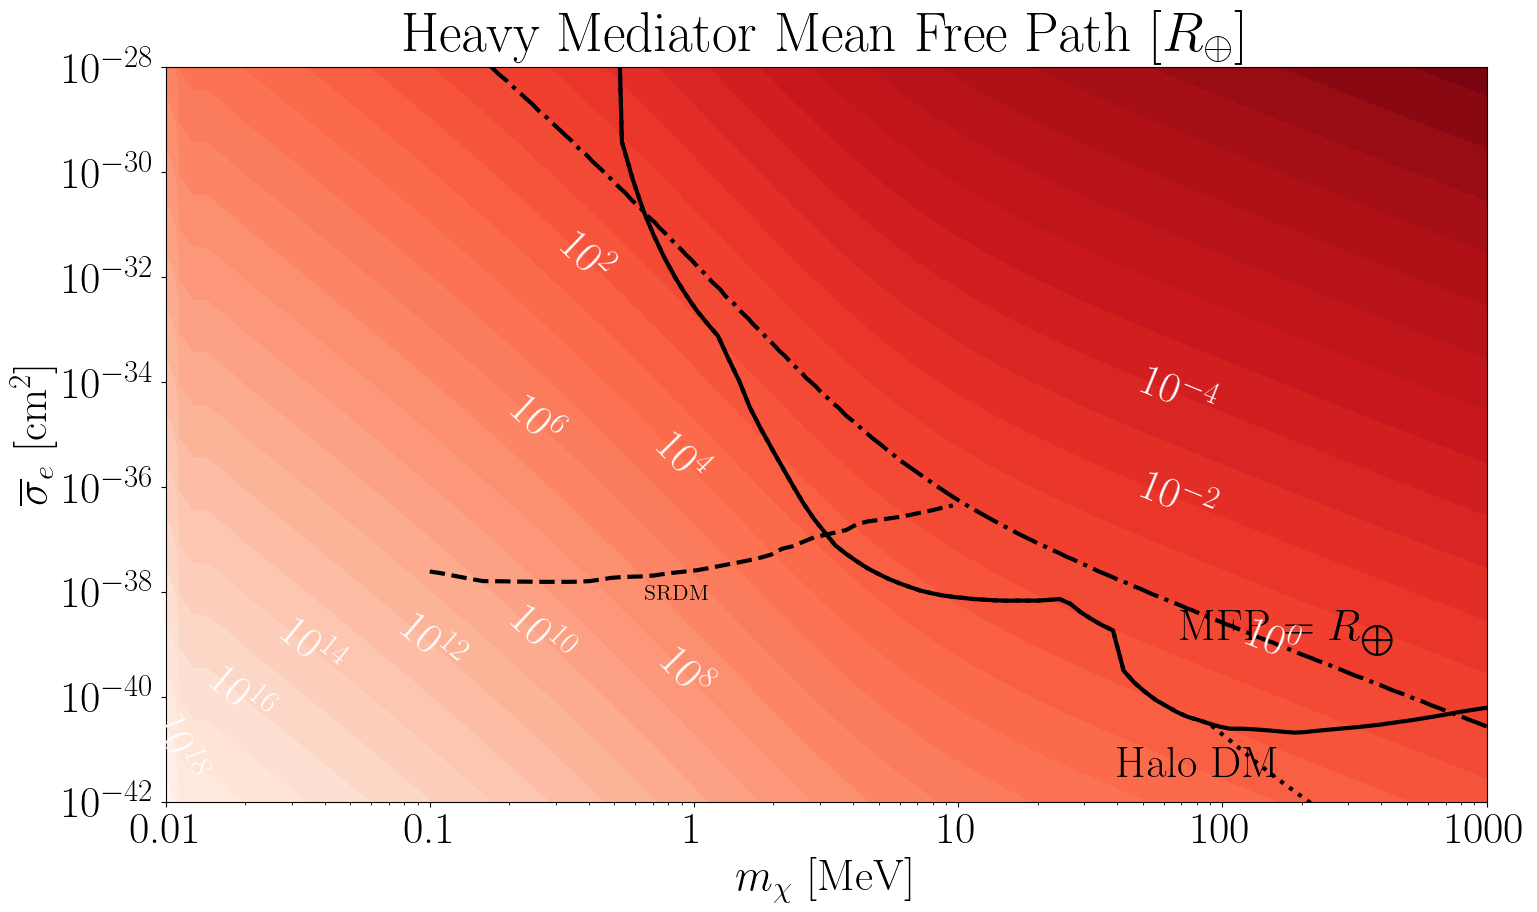

In [1]:
from Modulation import plotMeanFreePath
plotMeanFreePath(0,cmap_name='Reds_r',mX_range=(0.01, 1000), sigmaE_range=None)


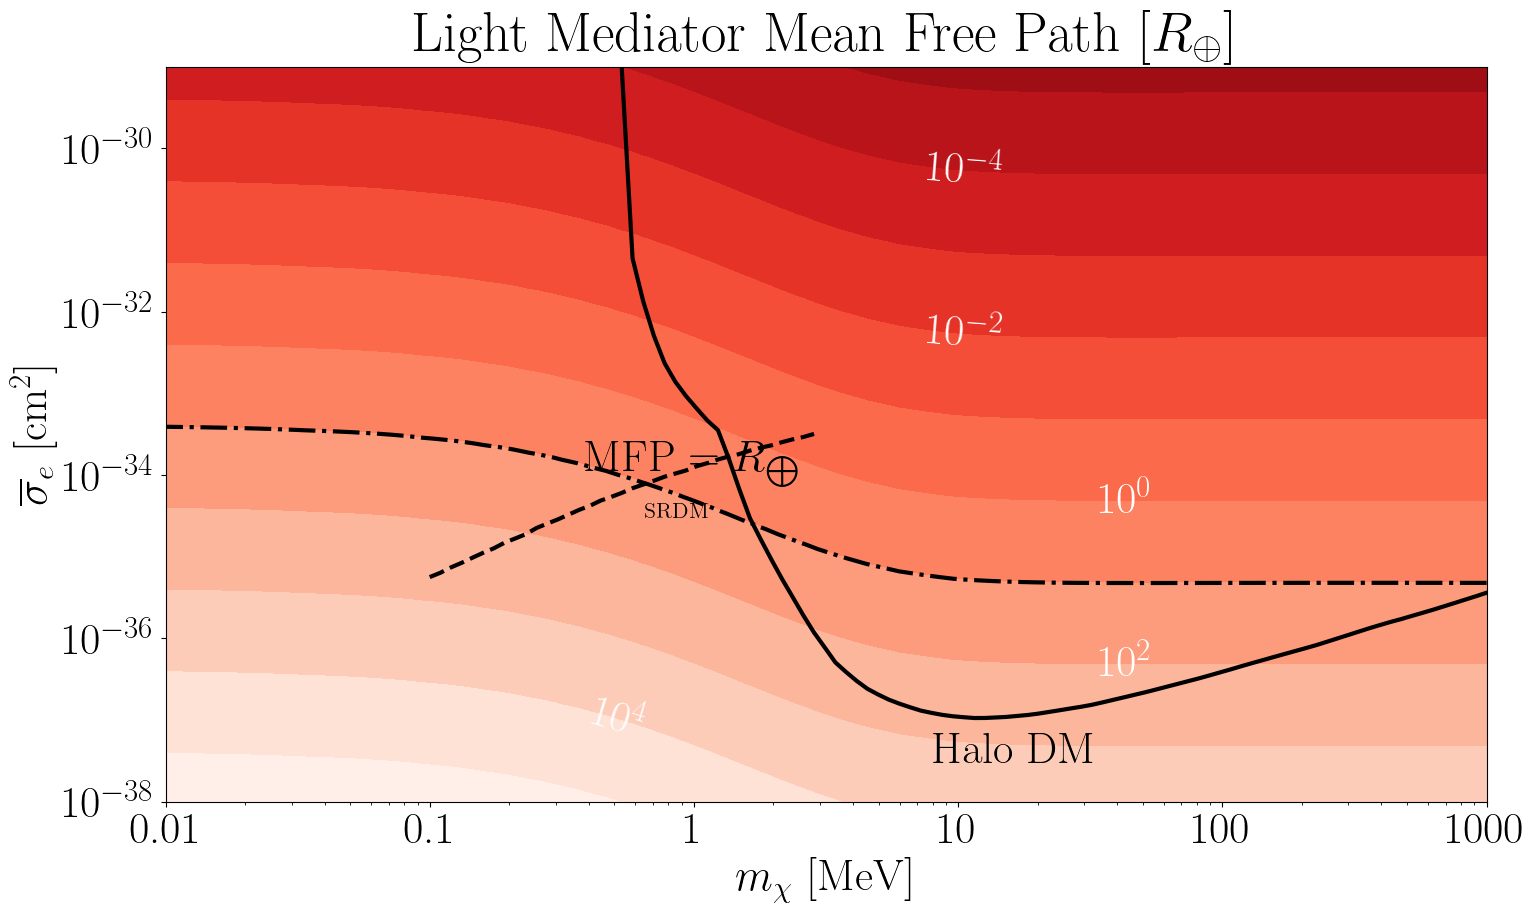

In [2]:
plotMeanFreePath(2,cmap_name='Reds_r',mX_range=(0.01, 1000), sigmaE_range=None)